In [1]:
!pip install shap

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import shap

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data


In [8]:
df = pd.read_csv('/content/heart_disease_uci.csv')

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [9]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


(920, 16)

In [10]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [11]:
df = df.drop(columns=['id', 'dataset'])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [12]:
df['num'] = (df['num'] > 0).astype(int) # 0 = ausência da doença / 1 = presença da doença

In [13]:
encoder = LabelEncoder()

for coluna in df.select_dtypes(include=['object']).columns:
    df[coluna] = encoder.fit_transform(df[coluna].astype(str))

In [15]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,2,1
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,3,1
3,37,1,2,130.0,250.0,0,2,187.0,0,3.5,0,0.0,2,0
4,41,0,1,130.0,204.0,0,0,172.0,0,1.4,3,0.0,2,0


In [14]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,0
restecg,0
thalch,55
exang,0
oldpeak,62


In [16]:
df = df.fillna(df.median())

In [17]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [18]:
X = df.drop('num', axis=1)
y = df['num']

In [19]:
print("Características:")
display(X.head())

print("\nAlvo:")
display(y.head())

Características:


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,2
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,3
3,37,1,2,130.0,250.0,0,2,187.0,0,3.5,0,0.0,2
4,41,0,1,130.0,204.0,0,0,172.0,0,1.4,3,0.0,2



Alvo:


,num
0,0
1,1
2,1
3,0
4,0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [21]:
padronizador = StandardScaler()

X_train = padronizador.fit_transform(X_train)
X_test = padronizador.transform(X_test)

In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [25]:
historico = model.fit(X_train,y_train,epochs=30,batch_size=16,validation_split=0.2,verbose=1)

Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4728 - loss: 0.7342 - val_accuracy: 0.5676 - val_loss: 0.6451
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5612 - loss: 0.6548 - val_accuracy: 0.6554 - val_loss: 0.5805
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6616 - loss: 0.6120 - val_accuracy: 0.7297 - val_loss: 0.5452
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7109 - loss: 0.5840 - val_accuracy: 0.7703 - val_loss: 0.5178
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7466 - loss: 0.5602 - val_accuracy: 0.7703 - val_loss: 0.4987
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7721 - loss: 0.5389 - val_accuracy: 0.7905 - val_loss: 0.4790
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7806 - loss: 0.5178 - val_accuracy: 0.7838 - val_loss: 0.4649
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7925 - loss: 0.4983 - val_accuracy: 0.7838 - val_

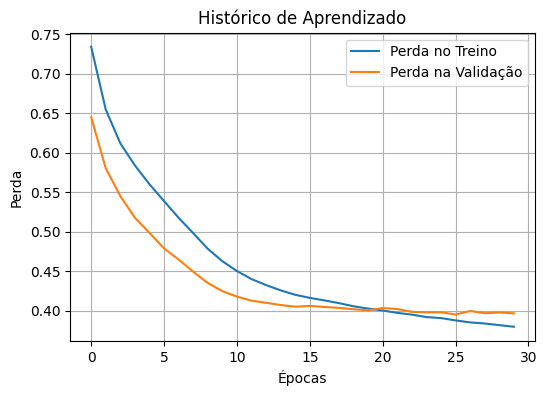

In [26]:
plt.figure(figsize=(6,4))
plt.plot(historico.history['loss'],label='Perda no Treino')
plt.plot(historico.history['val_loss'],label='Perda na Validação')
plt.title('Histórico de Aprendizado')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)

plt.show()

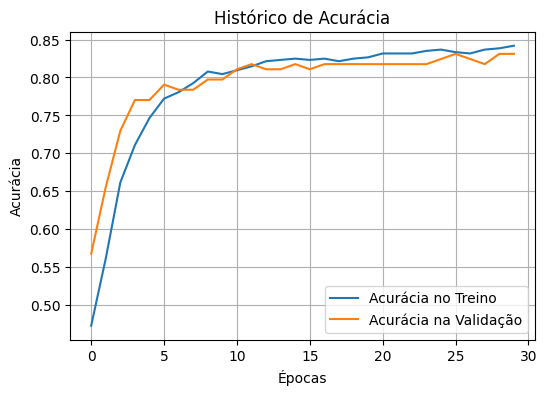

In [27]:
plt.figure(figsize=(6,4))
plt.plot(historico.history['accuracy'],label='Acurácia no Treino')
plt.plot(historico.history['val_accuracy'],label='Acurácia na Validação')
plt.title('Histórico de Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
perda, acuracia = model.evaluate(X_test,y_test,verbose=0)

print(f"Perda no Teste: {perda:.4f}")
print(f"Acurácia no Teste: {acuracia:.4f}")

Perda no Teste: 0.3814
Acurácia no Teste: 0.8261


In [29]:
previsoes_prob = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [30]:
previsoes = (previsoes_prob >= 0.5).astype(int)

In [31]:
print(classification_report(y_test,previsoes,target_names=['Sem doença', 'Com doença']))

              precision    recall  f1-score   support

  Sem doença       0.80      0.82      0.81        82
  Com doença       0.85      0.83      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.83      0.83       184



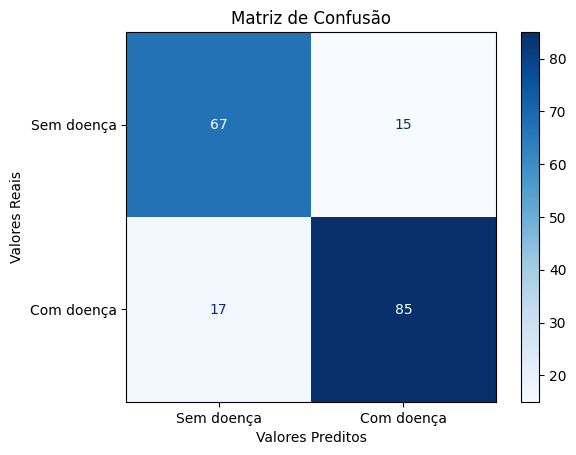

In [32]:
matriz_confusao = confusion_matrix(y_test,previsoes)
display_matriz = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,display_labels=['Sem doença', 'Com doença'])
display_matriz.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')
plt.show()

In [33]:
def model_predict(X):
    return (model.predict(X, verbose=0) >= 0.5).astype(int).reshape(-1)

In [34]:
explainer = shap.KernelExplainer(model_predict,X_train[:10])

In [35]:
shap_values = explainer.shap_values(X_test[:50])

  0%|          | 0/50 [00:00<?, ?it/s]

In [36]:
nomes_caracteristicas = X.columns.tolist()

print(nomes_caracteristicas)

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


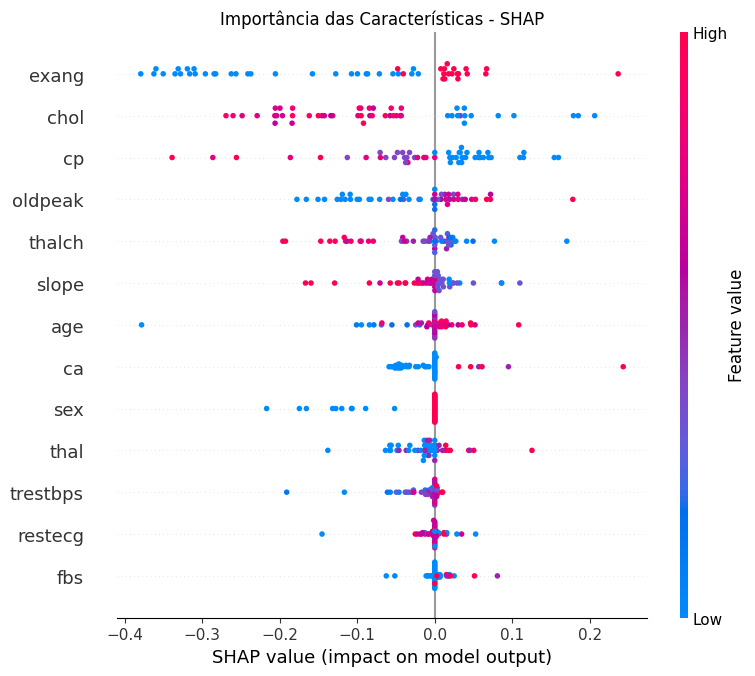

In [37]:
plt.figure(figsize=(7,5))
shap.summary_plot(shap_values,X_test[:50],feature_names=nomes_caracteristicas,show=False)
plt.title('Importância das Características - SHAP')
plt.show()

In [38]:
model.save('modelo_heart_disease.keras')

In [39]:
model_carregado = tf.keras.models.load_model('modelo_heart_disease.keras')